# OIBSIP Task 2 - Customer Segmentation Analysis

## Objective

The objective of this project is to segment customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering.

The analysis identifies distinct customer groups that can be targeted with different marketing strategies.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Retail_Sales.csv')
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


## 1. Load and Inspect the Dataset

The dataset is loaded and checked for its structure, data types, missing values, and duplicate records.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (2000, 11)

Column Names:
Index(['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender',
       'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale'],
      dtype='object')

Data Types:
transactions_id      int64
sale_date           object
sale_time           object
customer_id          int64
gender              object
age                float64
category            object
quantiy            float64
price_per_unit     float64
cogs               float64
total_sale         float64
dtype: object

Missing Values:
transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64

Duplicate Rows: 0


### Handling Missing Values

Missing values can affect the accuracy of the analysis. Missing age values are filled using the median age because age is a numerical variable.

Rows with missing values in important sales-related columns such as quantity, price per unit, COGS and total sales are removed because these values are required for the analysis.

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64


In [ ]:
# Fill missing age values with the median age
df['age'] = df['age'].fillna(df['age'].median())

# Remove rows where important sales information is missing
df = df.dropna(subset=['quantiy', 'price_per_unit', 'cogs', 'total_sale'])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
transactions_id    0
sale_date          0
sale_time          0
customer_id        0
gender             0
age                0
category           0
quantiy            0
price_per_unit     0
cogs               0
total_sale         0
dtype: int64


In [ ]:
df = df.rename(columns={'quantiy': 'quantity'})

print(df.columns)

Index(['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender',
       'age', 'category', 'quantity', 'price_per_unit', 'cogs', 'total_sale'],
      dtype='object')


In [ ]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

print(df.dtypes)

transactions_id             int64
sale_date          datetime64[ns]
sale_time                  object
customer_id                 int64
gender                     object
age                       float64
category                   object
quantity                  float64
price_per_unit            float64
cogs                      float64
total_sale                float64
dtype: object


In [ ]:
average_purchase_value = df['total_sale'].mean()

print("Average Purchase Value:", round(average_purchase_value, 2))

Average Purchase Value: 456.54


## 2. Descriptive Statistics

### Average Purchase Value

The average purchase value represents the average amount spent in a single transaction.

It is calculated by taking the mean of the `total_sale` column.

In [ ]:
purchase_frequency = df.groupby('customer_id')['transactions_id'].count()

print("Average Purchase Frequency:", round(purchase_frequency.mean(), 2))

Average Purchase Frequency: 12.88


### Purchase Frequency

Purchase frequency represents the number of transactions made by each customer.

The transactions are grouped by `customer_id` and counted to find how frequently customers make purchases. The average frequency is then calculated across all customers.

In [ ]:
customer_lifetime_value = df.groupby('customer_id')['total_sale'].sum()

print("Average Customer Lifetime Value:",
      round(customer_lifetime_value.mean(), 2))

Average Customer Lifetime Value: 5882.06


### Customer Lifetime Value

Customer Lifetime Value (CLV) represents the total value generated by a customer through their purchases.

Since this dataset does not contain future purchase information, the total amount spent by each customer is used as a simple CLV measure for this analysis.

In [ ]:
# Find the latest date in the dataset
reference_date = df['sale_date'].max()

# Calculate RFM values for each customer
rfm = df.groupby('customer_id').agg({
    'sale_date': 'max',
    'transactions_id': 'count',
    'total_sale': 'sum'
})

# Calculate Recency
rfm['Recency'] = (reference_date - rfm['sale_date']).dt.days

# Rename the other columns
rfm = rfm.rename(columns={
    'transactions_id': 'Frequency',
    'total_sale': 'Monetary'
})

# Keep only the selected RFM features
rfm = rfm[['Recency', 'Frequency', 'Monetary']]

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
1,20,76,30750.0
2,24,69,25295.0
3,0,76,38440.0
4,1,73,23580.0
5,1,63,30405.0


## 3. Feature Selection - RFM Analysis

RFM analysis is used to identify important customer purchasing behaviours.

The three selected features are:

- **Recency:** Number of days since the customer's most recent purchase. A lower value indicates a more recent purchase.
- **Frequency:** Number of transactions made by the customer. A higher value indicates that the customer purchases more frequently.
- **Monetary:** Total amount spent by the customer. A higher value indicates a customer with greater spending.

These three features are selected because they provide a simple and useful representation of customer purchasing behaviour for clustering.

In [ ]:
print("RFM Features:")
print(rfm.describe())

RFM Features:
          Recency   Frequency      Monetary
count  155.000000  155.000000    155.000000
mean    74.741935   12.883871   5882.064516
std    110.238221   11.805763   5345.486438
min      0.000000    2.000000    200.000000
25%     12.000000    7.000000   2737.500000
50%     34.000000   10.000000   4510.000000
75%     82.000000   15.000000   7412.500000
max    686.000000   76.000000  38440.000000


### RFM Feature Summary

The descriptive statistics help us understand the range and distribution of the selected RFM features before applying the clustering algorithm.

These features will be standardized before performing K-Means clustering because they have different numerical scales.

In [ ]:
features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
customer_id,,,
1,-0.498188,5.363543,4.667217
2,-0.461786,4.768691,3.643422
3,-0.680202,5.363543,6.110477
4,-0.671101,5.108606,3.321551
5,-0.671101,4.258817,4.602467


## 4. Data Standardisation

The RFM features have different numerical scales. For example, Recency is measured in days, while Monetary represents the amount spent.

StandardScaler is used to standardise the three features so that they are on a similar scale.

This is important for K-Means clustering because the clustering algorithm uses distances between data points. Standardisation prevents a feature with larger numerical values from having too much influence on the clusters.

In [ ]:
print("Mean of standardised features:")
print(rfm_scaled.mean())

print("\nStandard deviation of standardised features:")
print(rfm_scaled.std())

Mean of standardised features:
Recency      5.157165e-17
Frequency   -6.876220e-17
Monetary     0.000000e+00
dtype: float64

Standard deviation of standardised features:
Recency      1.003241
Frequency    1.003241
Monetary     1.003241
dtype: float64


### Standardisation Check

After standardisation, the feature values are centred around 0 and have a similar scale.

The standardised RFM data will now be used as input for the K-Means clustering algorithm.

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

## 5. K-Means Clustering - Elbow Method

The Elbow Method is used to determine a suitable number of clusters for K-Means.

K-Means is tested with different values of K, from 2 to 10. For each value, the inertia is recorded.

Inertia represents how close the data points are to the centre of their assigned cluster. As the number of clusters increases, inertia decreases.

The suitable K is selected by looking for an "elbow" point where the decrease in inertia starts to become smaller.

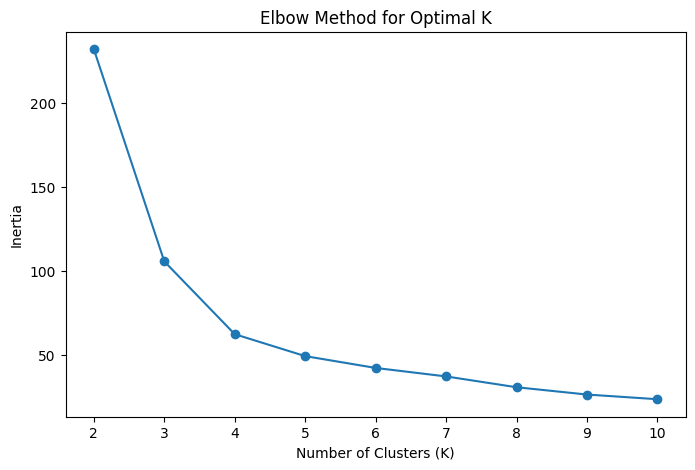

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

### Elbow Method Observation

The elbow point in the graph indicates the suitable number of clusters for the K-Means algorithm. Based on the graph, K = 3 is selected for the customer segmentation analysis.

In [ ]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
customer_id,,,,
1,20,76,30750.0,2
2,24,69,25295.0,2
3,0,76,38440.0,2
4,1,73,23580.0,2
5,1,63,30405.0,2


## 6. K-Means Clustering

K-Means clustering is applied to divide customers into different groups based on their Recency, Frequency and Monetary values.

The number of clusters is selected using the Elbow Method. Each customer is assigned to one cluster based on similar purchasing behaviour.

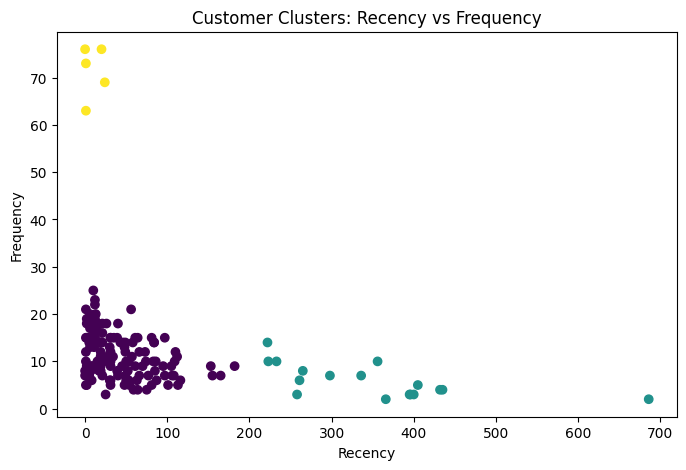

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    c=rfm['Cluster']
)

plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Customer Clusters: Recency vs Frequency')

plt.show()

### Cluster Visualisation: Recency vs Frequency

The scatter plot shows the customer clusters based on Recency and Frequency.

Customers with similar purchasing patterns are grouped into the same cluster. The plot helps us visually understand the differences between the customer segments.

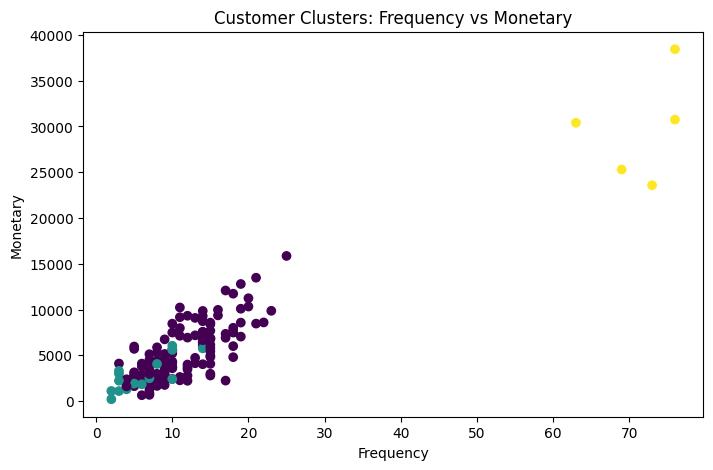

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Frequency vs Monetary')

plt.show()

### Cluster Visualisation: Frequency vs Monetary

This scatter plot shows the relationship between purchase frequency and total spending for each customer.

The different clusters represent groups of customers with similar purchasing frequency and spending behaviour.

In [ ]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,41.89,11.57,5383.12
1,351.00,5.94,2782.06
2,9.20,71.40,29694.00


## 7. Cluster Profiling

The mean Recency, Frequency and Monetary values are calculated for each cluster.

This helps us understand the purchasing behaviour of each customer segment.

- Lower Recency means the customer purchased more recently.
- Higher Frequency means the customer makes purchases more often.
- Higher Monetary means the customer spends more money.

In [ ]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    133
1     17
2      5
Name: count, dtype: int64


### Customer Type Identification

The cluster profile can be used to describe each customer segment.

Customers with low Recency, high Frequency, and high Monetary values can be considered high-value or loyal customers.

Customers with high Recency and low Frequency may be inactive or at-risk customers.

Customers with moderate values can be considered regular or potential customers.

The exact customer type is determined by comparing the mean RFM values of each cluster.

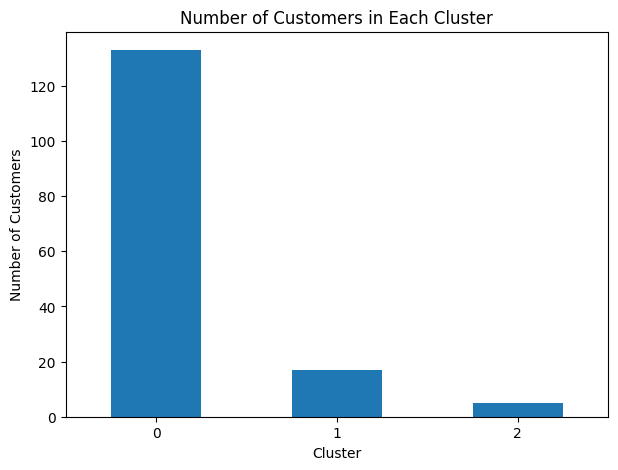

In [ ]:
plt.figure(figsize=(7, 5))

cluster_counts.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')

plt.xticks(rotation=0)

plt.show()

## 8. Customer Count by Cluster

The bar chart shows the number of customers belonging to each cluster.

This helps us understand the size of each customer segment and identify which segments contain the largest or smallest number of customers.

In [ ]:
cluster_profile.round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,41.89,11.57,5383.12
1,351.00,5.94,2782.06
2,9.20,71.40,29694.00


### Customer Segment Profiles

Based on the average RFM values, the three clusters can be interpreted as follows:

- **Cluster 0 - Regular Customers:** These customers purchase fairly recently and have moderate purchase frequency and spending.

- **Cluster 1 - At-Risk / Inactive Customers:** These customers have not purchased recently and have the lowest purchase frequency and spending.

- **Cluster 2 - High-Value / Loyal Customers:** These customers purchase very recently, have a high purchase frequency, and have the highest spending among all segments.

## Marketing Recommendations

Different marketing strategies can be used for each customer segment:

- **Cluster 0 - Regular Customers:** Provide personalised offers, product recommendations and discounts to encourage more frequent purchases.

- **Cluster 1 - At-Risk / Inactive Customers:** Use re-engagement campaigns, special discounts and reminders to encourage these customers to return.

- **Cluster 2 - High-Value / Loyal Customers:** Reward these customers with loyalty benefits, exclusive offers, early access to new products and personalised rewards to maintain their engagement.

These targeted strategies can help improve customer retention, increase repeat purchases, and strengthen customer relationships.

# 10. Conclusion

The customer segmentation analysis was performed using RFM (Recency, Frequency, and Monetary) features and K-Means clustering.

The analysis identified three customer segments with different purchasing behaviours:

- **Cluster 0 - Regular Customers:** This is the largest customer group, with moderate purchase frequency and spending.
- **Cluster 1 - At-Risk / Inactive Customers:** These customers have not purchased recently and have lower purchase frequency and spending.
- **Cluster 2 - High-Value / Loyal Customers:** This is the smallest group but has the highest purchase frequency and spending, along with very recent purchases.

The segmentation helps the business understand different customer behaviours and create targeted marketing strategies. Re-engagement campaigns can be used for inactive customers, personalised offers can be used for regular customers, and loyalty rewards can be provided to high-value customers.

Overall, K-Means clustering combined with RFM analysis provides a useful way to divide customers into meaningful segments and support data-driven marketing decisions.